In [1]:
import pandas as pd

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt

import scipy.stats as st
import numpy as np

In [2]:
likelihoods_gapfill_betaine = pd.read_csv('../../1_figure_CL_proof_of_concept/output/gapfill_betaine_1plex_summary.csv', index_col=0)
likelihoods_gapfill_no_betaine = pd.read_csv('../output/gapfill_no_betaine_1plex_summary.csv', index_col=0)

In [3]:
merged_likelihoods = likelihoods_gapfill_betaine.add_suffix('_gapfill_betaine') \
    .join(likelihoods_gapfill_no_betaine.add_suffix('_gapfill_no_betaine'))


/tmp/ipykernel_253979/1875080949.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[0][i] >= data[1][i]:
/tmp/ipykernel_253979/1875080949.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[0][i] < data[1][i]:
/tmp/ipykernel_253979/1875080949.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.plot([1,2], [data[0][i], data[1][i]], color='k', alpha=alpha, linewidth=0.7)
/tmp/ipykernel_253979/1875080949.py:12: F

n=95
Median (- Betaine): 0.5459859703819174
Median (Gapfill + Betaine): 0.7031524547803617
Median FC: 1.1729171226426218
WilcoxonResult(statistic=241.0, pvalue=1.1504051854799439e-13)


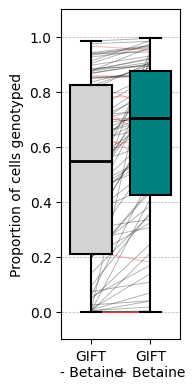

In [4]:
prefix = 'prop_genotyped_'

fig, ax = plt.subplots(figsize=(2,4))
data = [
    merged_likelihoods.dropna(subset=[prefix + 'gapfill_no_betaine', prefix + 'gapfill_betaine'])[prefix + 'gapfill_no_betaine'],
    merged_likelihoods.dropna(subset=[prefix + 'gapfill_no_betaine', prefix + 'gapfill_betaine'])[prefix + 'gapfill_betaine'],
]

alpha = 0.3
for i in range(len(data[0])): ### add lines for individual datapoints
    if data[0][i] >= data[1][i]:
        ax.plot([1,2], [data[0][i], data[1][i]], 'red', alpha=alpha, linewidth=0.7)
    if data[0][i] < data[1][i]:
        ax.plot([1,2], [data[0][i], data[1][i]], color='k', alpha=alpha, linewidth=0.7)

bp = ax.boxplot(
    data,
    tick_labels=[
        'GIFT\n- Betaine',
        'GIFT\n+ Betaine'
    ],
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey', color='k',linewidth=1.5),
    medianprops=dict(color='k', linewidth=2),
    whiskerprops=dict(color='k', linewidth=1.5),
    capprops=dict(color='k', linewidth=1.5),
    showfliers=False, widths=0.7
)
# Color boxes: grey for no betaine, teal for betaine
bp['boxes'][0].set_facecolor('lightgrey')
bp['boxes'][1].set_facecolor('teal')
ax.set_ylabel('Proportion of cells genotyped')
# ax.set_ylim(0, 6)
ax.grid(True, axis='y', linestyle='--', linewidth=0.5)
plt.tight_layout()

print('n=' + str(len(data[0])))

print("Median (- Betaine):", np.median(data[0]))
print("Median (Gapfill + Betaine):", np.median(data[1]))
print('Median FC:', (data[1] / data[0]).median())
print(st.wilcoxon(data[0], data[1], alternative='less'))

ax.set_ylim(-0.1,1.1)

plt.savefig('../plots/betaine_vs_no_betaine_prop_genotyped_boxplot.pdf')